# 14_损失函数-对数似然损失

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这里，咱们和大家介绍一下对数似然损失\~

回顾一下损失函数。简单说，**损失函数**就是用来衡量模型预测结果有多“差”的一个东西。

比如你做了个模型，预测明天会不会下雨，模型给了一个概率80%会下雨，但实际上没下雨。损失函数就是告诉你，这个预测“差”多少，模型哪里做得不够好。

### 对数似然损失

对数似然损失是统计学和机器学习里常用的一种损失函数，尤其是在分类问题（比如判断图片里是猫还是狗）中很常见。

它背后的意思其实挺直白的：

- 你的模型会给出每个类别的概率，比如判断是不是猫，模型说有90%是猫。
- 你知道真正的答案，比如其实是猫。
- 你希望模型给正确答案的概率越大越好，这样模型才靠谱。
- 对数似然损失就是用对数来衡量模型给正确答案的概率，概率越大，损失越小；概率越小，损失越大。

### 为什么用对数？

因为概率是0到1之间的小数，直接用概率可能不好算，乘起来的概率会变得非常小。

用对数（log）可以把乘法变成加法，计算更方便，而且对数有个好处是：

- 当概率接近1时，对数值接近0（损失小）
- 当概率接近0时，对数值变得很大（损失大）

这正好符合我们想要的效果：模型给的正确答案概率越高，损失越小。

### 举个简单例子

假设你有个二分类问题（猫或狗），模型给猫的概率是0.9，给狗的概率是0.1，真实标签是“猫”。

对数似然损失大致是取模型给“猫”的概率0.9的对数，然后取负数：

损失 = -log(0.9) ≈ 0.105（比较小，说明预测不错）

如果模型给“猫”的概率只有0.1，损失 = -log(0.1) ≈ 2.3（比较大，说明预测差）

## 原理详解

### 从概率角度看分类

假设我们做的是一个**二分类问题**，也就是要判断样本 $x$ 属于类别 $y = 1$ 还是 $y = 0$。

模型输出的是：


$$
\hat{y} = P(y=1 \mid x; \theta)
$$


其中：

- $\hat{y} \in (0,1)$ 是模型预测为 1 的概率
- $\theta$ 是模型参数
- 因此，$P(y=0 \mid x; \theta) = 1 - \hat{y}$

我们希望模型学到一组参数 $\theta$，使得**真实标签** $y$ **在当前输入** $x$ **下的预测概率最大**。这就是**最大似然估计**。

### 最大似然估计（MLE）

我们有一个训练集：


$$
\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^{N}
$$


对每个样本 $(x^{(i)}, y^{(i)})$，模型预测的概率为：


$$
P(y^{(i)} \mid x^{(i)}; \theta) = \hat{y}^{(i)} \quad \text{(若 } y^{(i)} = 1\text{)}\quad \text{或} \quad 1 - \hat{y}^{(i)} \quad \text{(若 } y^{(i)} = 0\text{)}
$$


这可以统一地写为：


$$
P(y^{(i)} \mid x^{(i)}; \theta) = (\hat{y}^{(i)})^{y^{(i)}} \cdot (1 - \hat{y}^{(i)})^{1 - y^{(i)}}
$$


整个数据集的似然函数（Likelihood）是：


$$
\mathcal{L}(\theta) = \prod_{i=1}^{N} P(y^{(i)} \mid x^{(i)}; \theta)= \prod_{i=1}^{N} (\hat{y}^{(i)})^{y^{(i)}} \cdot (1 - \hat{y}^{(i)})^{1 - y^{(i)}}
$$


我们要最大化这个似然函数。

### 对数似然（Log Likelihood）

由于连乘计算不方便，且容易导致数值下溢，我们取对数：


$$
\log \mathcal{L}(\theta) = \sum_{i=1}^{N} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$


这是我们要最大化的目标函数，称为**对数似然函数（Log Likelihood）**。

### 对数似然损失函数（Log-Likelihood Loss）

在机器学习训练中，我们最小化损失函数。所以我们取对数似然函数的**负数**作为损失函数：


$$
\boxed{\mathcal{L}_{\text{loss}}(\theta) = -\sum_{i=1}^{N} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]}
$$


这是经典的**二分类交叉熵损失函数（cross-entropy loss）**，也称为对数似然损失函数。

如果是单个样本，则为：


$$
\boxed{\mathcal{L}_{\text{loss}} = -\left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]}
$$


### 为什么这个损失有效？

我们从直觉上理解一下：

- 如果 $y = 1$，我们希望 $\hat{y} \to 1$，此时 $\log(\hat{y}) \to 0$，损失趋近于0。
- 如果 $y = 0$，我们希望 $\hat{y} \to 0$，此时 $\log(1 - \hat{y}) \to 0$，损失也趋近于0。
- 如果预测错了，比如 $y = 1$ 但 $\hat{y}$ 很小（比如0.01），则损失为 $-\log(0.01) \approx 4.6$，非常大。

也就是说：**这个损失函数惩罚“自信但错误”的预测特别严重。**

## 算法流程（训练过程）

整个训练模型的流程如下：

#### Step 1: 初始化参数 $\theta$

通常是模型的权重（比如逻辑回归权重、神经网络的参数等）

#### Step 2: 前向传播（Forward Pass）

对于每个输入 $x^{(i)}$，计算预测概率：


$$
\hat{y}^{(i)} = \sigma(z^{(i)}) = \frac{1}{1 + e^{-z^{(i)}}}, \quad z^{(i)} = \theta^\top x^{(i)}
$$


这里使用的是 sigmoid 激活函数，适用于二分类。

#### Step 3: 计算损失

对所有样本，使用对数似然损失函数：


$$
\mathcal{L}_{\text{loss}} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$


#### Step 4: 反向传播（求梯度）

根据损失函数对参数 $\theta$ 求偏导，得到梯度：


$$
\frac{\partial \mathcal{L}}{\partial \theta} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}^{(i)} - y^{(i)}) x^{(i)}
$$


这个形式是逻辑回归梯度，非常简洁。

#### Step 5: 参数更新

使用梯度下降法：


$$
\theta \leftarrow \theta - \eta \cdot \frac{\partial \mathcal{L}}{\partial \theta}
$$


重复 Steps 2–5，直到损失函数收敛或达到设定轮数。

---

## 推广到多分类（Softmax + 多类对数似然）

对于多分类问题（比如分成3类），我们用 **Softmax** 输出每个类别的概率：


$$
\hat{y}_k = \frac{e^{z_k}}{\sum_{j} e^{z_j}} \quad (k = 1, 2, ..., K)
$$


对数似然损失推广为：


$$
\mathcal{L}_{\text{loss}} = -\sum_{i=1}^{N} \sum_{k=1}^{K} y_k^{(i)} \log(\hat{y}_k^{(i)})
$$


其中 $y_k^{(i)}$ 是 one-hot 编码，只有正确的类是1，其他为0。

## 总结

| 名称 | 数学形式 |
|-|-|
| 对数似然（Log-likelihood） | $\sum y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})$ |
| 对数似然损失（负号） | $-[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) ]$ |
| 多分类形式 | $-\sum_k y_k \log(\hat{y}_k)$ |
| 本质目标 | 最大化正确类别的预测概率（最大似然估计） |

## 完整案例

这里，写一个基于二分类任务的完整案例，用逻辑回归模型训练一个真实数据集（用sklearn自带的乳腺癌数据集），使用对数似然损失（交叉熵），并做训练过程损失曲线可视化，并演示算法优化\~

案例：用对数似然损失训练逻辑回归模型识别乳腺癌良恶性。

样本总数: 569
特征数: 30
正负样本比例: [212 357]
测试集准确率 (Accuracy): 0.9860
测试集AUC (ROC AUC): 0.9977


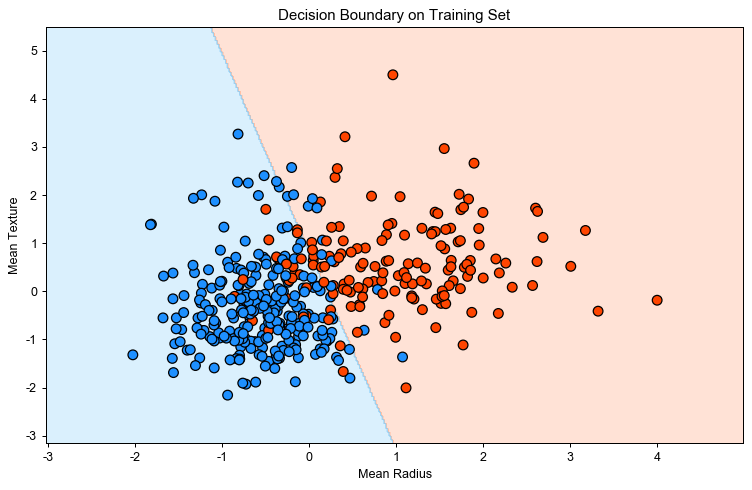

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# 1. 加载数据集
data = load_breast_cancer()
X = data.data      # 特征矩阵
y = data.target    # 标签（0=良性,1=恶性）

print("样本总数:", X.shape[0])
print("特征数:", X.shape[1])
print("正负样本比例:", np.bincount(y))

# 2. 数据切分（训练集/测试集）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# 3. 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. 构造逻辑回归模型 (使用 sklearn 默认的对数似然损失)
# 使用L2正则化，C=1.0表示正则化强度，solver使用liblinear适合小样本数据
model = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', max_iter=100)

# 5. 训练模型
model.fit(X_train, y_train)

# 6. 预测测试集
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 7. 评估指标
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"测试集准确率 (Accuracy): {acc:.4f}")
print(f"测试集AUC (ROC AUC): {auc:.4f}")

# 8. 可视化训练集上的部分特征的决策边界

# 选两个最相关的特征: 'mean radius'(feature 0) 和 'mean texture'(feature 1)
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

# 用只考虑前两个特征，训练新的模型用于决策边界可视化
model_2d = LogisticRegression(penalty='l2', C=1.0, solver='liblinear')
model_2d.fit(X_train_2d, y_train)

# 创建网格，用于绘制决策边界
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 9. 绘制决策边界和训练样本点
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFA07A', '#87CEFA'])
cmap_bold = ListedColormap(['#FF4500', '#1E90FF'])

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap_bold,
            edgecolor='k', s=60)
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Decision Boundary on Training Set')
plt.show()

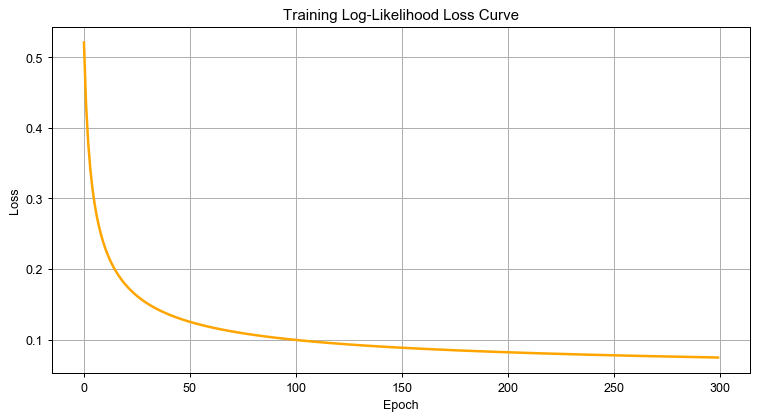

In [3]:
# 10. 可视化训练过程中对数似然损失变化（自定义实现SGD训练并记录损失）
# 这里演示损失函数曲线，展示模型如何收敛

class LogisticRegressionSGD:
    def __init__(self, lr=0.01, epochs=200, reg_lambda=0.01):
        self.lr = lr
        self.epochs = epochs
        self.reg_lambda = reg_lambda

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, X, y, weights):
        m = len(y)
        h = self.sigmoid(X @ weights)
        # 对数似然损失 + L2正则项
        loss = (-1 / m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))
        reg = (self.reg_lambda / (2 * m)) * np.sum(weights[1:] ** 2)  # 不正则化bias
        return loss + reg

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.loss_history = []

        for epoch in range(self.epochs):
            h = self.sigmoid(X @ self.weights)
            gradient = (1 / m) * (X.T @ (h - y)) + (self.reg_lambda / m) * np.r_[0, self.weights[1:]]
            self.weights -= self.lr * gradient

            loss = self.compute_loss(X, y, self.weights)
            self.loss_history.append(loss)

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# 11. 添加偏置列（截距项）
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# 12. 训练自定义SGD逻辑回归模型
sgd_model = LogisticRegressionSGD(lr=0.1, epochs=300, reg_lambda=0.1)
sgd_model.fit(X_train_bias, y_train)

# 13. 绘制训练损失曲线
plt.figure(figsize=(10, 5))
plt.plot(sgd_model.loss_history, color='orange', linewidth=2)
plt.title('Training Log-Likelihood Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [4]:
# 14. 评估自定义模型
y_pred_sgd = sgd_model.predict(X_test_bias)
y_proba_sgd = sgd_model.predict_proba(X_test_bias)

acc_sgd = accuracy_score(y_test, y_pred_sgd)
auc_sgd = roc_auc_score(y_test, y_proba_sgd)

print(f"SGD Model Accuracy: {acc_sgd:.4f}")
print(f"SGD Model ROC AUC: {auc_sgd:.4f}")

SGD Model Accuracy: 0.9860
SGD Model ROC AUC: 0.9971


#### 1. 加载数据

我们使用 `sklearn.datasets` 中的乳腺癌数据集。这个数据集是二分类问题，目标是预测乳腺肿块良恶性（0=良性，1=恶性），共569个样本，30个特征。

#### 2. 数据划分

用 `train_test_split` 将数据随机分为训练集（75%）和测试集（25%），同时保持类别分布一致（`stratify=y`）。

#### 3. 标准化特征

对每个特征做均值为0、方差为1的标准化，使不同特征处于同一尺度，避免某些特征数值大而影响训练。

#### 4. 使用 sklearn 的 LogisticRegression 模型

逻辑回归是对数似然损失函数的经典实现，`penalty='l2'` 表示加了L2正则项防止过拟合，`solver='liblinear'` 是一种适合小数据的优化算法。

#### 5. 训练模型

调用 `.fit()` 方法训练模型，自动最小化对数似然损失。

#### 6. 预测测试集

得到测试集预测的标签 `y_pred` 和预测概率 `y_proba`。

#### 7. 计算评估指标

- **Accuracy**: 准确率，即预测正确的比例
- **ROC AUC**: ROC曲线下面积，衡量分类器区分正负样本能力，越接近1越好

#### 8. 可视化决策边界

选取两个最相关特征：`mean radius` 和 `mean texture`，只用它们训练新的逻辑回归模型，画出决策边界。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

#### 9. 自定义实现带正则的逻辑回归 SGD

通过自己写一个类，演示如何用梯度下降训练模型，并在每个epoch计算对数似然损失，记录损失变化。

- `compute_loss` 函数里加了L2正则项
- 梯度计算包含正则项
- 使用sigmoid激活函数映射线性组合为概率

#### 10. 添加偏置列

为了把偏置 $b$ 作为权重向量一部分处理，给 $X$ 增加一列常数1。

#### 11. 训练自定义模型

训练300轮，学习率0.1，正则项系数0.1，观察损失是否平滑收敛。

#### 12. 绘制训练损失曲线

可以清晰展示训练过程中损失递减趋势。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

#### 13. 评估自定义模型

计算自定义模型在测试集上的准确率和AUC，与 sklearn 版模型做对比。

## 算法优化建议

**正则化**：防止过拟合，尤其是高维特征。这里用L2正则是经典选择。

**学习率调整**：可用自适应学习率(如Adam, RMSProp)，让收敛更快更稳。

**特征选择/降维**：使用PCA或L1正则，去除无关特征，简化模型。

**批量梯度下降**：可用mini-batch SGD，提升效率。

**更多训练轮次**：观察训练和验证损失曲线，避免欠拟合或过拟合。

## 模型分析

### 优缺点

**优点**

1. **概率解释强**：对数似然损失函数天然地基于概率模型（最大似然估计），输出的是概率值而非标签，从而更适合需要概率判断的任务，如风险评分、广告点击预测、医学诊断等。
2. **连续可导，适合优化**：它是一个连续、可微的凸函数，非常适合梯度下降法优化，能保证全局最优（在凸模型下，如逻辑回归）。
3. **数学基础扎实**：对数似然源自统计学，是最大似然估计的直接目标函数，具有严密的数学推导和理论支持。
4. **与交叉熵等价（在分类中）**：在二分类/多分类问题中，它等价于交叉熵损失，因此也具备交叉熵对样本区分能力强的优势，能放大错误分类的惩罚。
5. **广泛支持，主流库普遍采用**：从 scikit-learn、TensorFlow 到 PyTorch，几乎所有主流框架都内置支持，便于工程化和快速部署。

**缺点**

1. **对异常点敏感**：对数似然损失在分类错且置信度高的样本（如预测为 0.99 却标签是 0）会惩罚极大，可能对异常样本过分惩罚，导致训练不稳定。
2. **需要模型能输出概率**：必须是概率型模型（如 Logistic Regression, Softmax Regression），对非概率模型（如 SVM、树模型）则不适用。
3. **不适合处理类别不平衡严重场景**：如果数据类别高度不平衡，模型可能倾向于预测多数类，损失函数无法自然处理不平衡，需要额外加权或采样。
4. **线性模型受限于特征表示**：如果你用的是 Logistic Regression + 对数似然损失，模型本质是线性的，若特征表达能力不强，效果会受限。

### 对数似然损失 vs 相似算法对比

| 损失函数 / 算法 | 适用任务 | 优势 | 劣势 | 输出类型 |
|-|-|-|-|-|
| **对数似然损失** | 分类（逻辑回归） | 概率输出、理论完备、优化稳定 | 对异常值敏感，需概率模型支持 | 概率 |
| **平方损失（MSE）** | 回归、分类（偶尔） | 简单、易理解 | 在分类中不如对数似然有效，惩罚小概率错误不够 | 数值（概率或输出） |
| **0-1损失** | 理论分析、评估指标 | 可解释性强（直接反映错误数量） | 不可导、不能用于梯度优化 | 离散标签（0/1） |
| **交叉熵损失（Cross-Entropy）** | 分类（深度学习中） | 与对数似然等价于分类问题中，放大错误惩罚 | 同样对异常值敏感，对样本权重不敏感 | 概率 |
| **Hinge 损失（SVM）** | 分类（SVM） | 强化边界间隔，鲁棒性较高 | 不能输出概率、不适合概率型任务 | 置信度（间隔） |
| **Focal Loss** | 类别不平衡分类 | 专门处理难分类样本和类别不均衡问题 | 增加调参复杂度，非标准损失 | 概率 |
| **KL散度损失** | 分布匹配/多分类 | 衡量两个分布差异，常用于知识蒸馏和对抗训练 | 需要两个概率分布作为输入，要求更高 | 概率分布 |

### 适用情境讨论：何时使用对数似然损失，何时考虑替代方案？

#### 适合使用对数似然损失的场景：

- 你需要**概率输出**，如医疗决策、信贷风控、广告点击预测
- 你使用的是**逻辑回归、Softmax 多分类、深度分类模型**
- 数据类别大致均衡，或者你能对不平衡样本做加权处理
- 你希望模型学习到的是「预测概率尽量接近真实标签概率」

#### 应考虑替代算法的场景：

- 如果你的任务是**回归问题**（预测温度、价格等），应使用 **MSE/MAE** 等损失
- 如果数据严重类别不平衡，可以考虑：

  - 使用 **Focal Loss**（自动强化难样本学习）
  - 使用 **类别加权交叉熵**
- 如果你不关心概率，只关心分类边界和鲁棒性，可考虑：

  - **Hinge Loss + SVM**
- 如果你做的是知识蒸馏或分布拟合类任务（如GAN），使用：

  - **KL散度** 或 **Jensen-Shannon 散度**
- 对异常值非常敏感的任务，建议使用**鲁棒损失**如 Huber Loss 或 Smooth L1 Loss

### 总结

对数似然损失是一种在统计学上严密、在机器学习中高效的分类损失函数，适合需要概率解释和可优化性的场景，特别适用于逻辑回归和深度分类网络。在模型输出概率、任务需要决策依据、样本分布相对均衡的前提下，它几乎是最佳选择。而在面对高噪声、类别失衡、或非概率模型时，其他损失函数（如Focal Loss、Hinge Loss）或更鲁棒的替代方案可能更合适。